In [1]:
import os

import matplotlib as mpl
import numpy as np
import scipy.io as spio
from cil.framework import AcquisitionData, AcquisitionGeometry, ImageGeometry
from cil.io import TIFFStackReader, TIFFWriter
from cil.io.TIFF import TIFFWriter
from cil.plugins.astra import FBP
from cil.processors import TransmissionAbsorptionConverter

# from cil.recon import FBP, FDK
from cil.utilities.display import show2D
from cil.utilities.jupyter import islicer
from gvxrPython3 import gvxr
from matplotlib import pyplot as plt
from RXSolutionsDataReader import RXSolutionsDataReader
from skimage.measure import profile_line
from utils import (
    find_optimal_stepwedge_size,
    get_optimal_poly_fit,
    setPolySpectrum,
    transmission_to_absorption,
)

# Configure matplotlib graph
font = {
    "family": "serif",
    "size": 15,
}
mpl.rc("font", **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

# Move all gVXR logs to a file
gvxr.useLogFile("beam-hardening.log")

xpecgen is not install, you won't be able to load a beam spectrum using xpecgen


In [2]:
INPUT_PATH = "../../../data-nalin/Wire-NoFilter-17.54umvx"
OUTPUT_PATH = "../../output_data/beam-hardening/rx-sol"

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

# 1. Read data in

In [3]:
number_of_slices_to_reconstruct = 0 # Use 0 to compute it automatically
scaling_factor = 2

if scaling_factor == 1:
    roi = None
else:
    roi = {"axis_1": [None, None, scaling_factor], "axis_2": [None, None, scaling_factor]}

CSV_file_path_1 = os.path.join(INPUT_PATH, "geometry.csv")
CSV_file_path_2 = os.path.join(INPUT_PATH, "geom.csv")

if os.path.exists(CSV_file_path_1):
    CSV_file_path = CSV_file_path_1
elif os.path.exists(CSV_file_path_2):
    CSV_file_path = CSV_file_path_2
else:
    raise OSError(CSV_file_path_1 + " and " + CSV_file_path_2 + " do not exist")

In [4]:
reader = RXSolutionsDataReader(CSV_file_path, roi=roi)

In [5]:
flexible_acq_data = reader.read()

# Pre-processing and Reconstruction

In [6]:
# Prepare the data for Astra
flexible_acq_data.reorder(order="astra")

flexible_data_exp = TransmissionAbsorptionConverter()(flexible_acq_data)

In [7]:
# Use the system magnification to compute the voxel size
mag = flexible_data_exp.geometry.magnification
mean_mag = np.mean(mag)
print("Mean magnification: ", mean_mag)

voxel_size_xy = flexible_data_exp.geometry.config.panel.pixel_size[0] / mean_mag
voxel_size_z = flexible_data_exp.geometry.config.panel.pixel_size[1] / mean_mag

voxel_size_xy = min(voxel_size_xy, voxel_size_z)
voxel_size_z = voxel_size_xy

# Create an image geometry
num_voxel_xy = int(np.ceil(flexible_data_exp.geometry.config.panel.num_pixels[0]))
num_voxel_z = int(np.ceil(flexible_data_exp.geometry.config.panel.num_pixels[1]))

if number_of_slices_to_reconstruct > 0:
    num_voxel_z = number_of_slices_to_reconstruct // scaling_factor

image_geometry = ImageGeometry(
    num_voxel_xy, num_voxel_xy, num_voxel_z,
    voxel_size_xy, voxel_size_xy, voxel_size_z,
)

print(image_geometry)

Mean magnification:  8.55333927451562
Number of channels: 1
channel_spacing: 1.0
voxel_num : x956,y956,z956
voxel_size : x0.03507401395831328,y0.03507401395831328,z0.03507401395831328
center : x0,y0,z0



In [8]:
# Reconstruct using FDK
# Instantiate the reconstruction algorithm
fdk = FBP(image_geometry, flexible_data_exp.geometry)
fdk.set_input(flexible_data_exp)

# Perform the actual CT reconstruction
flexible_recon = fdk.get_output()

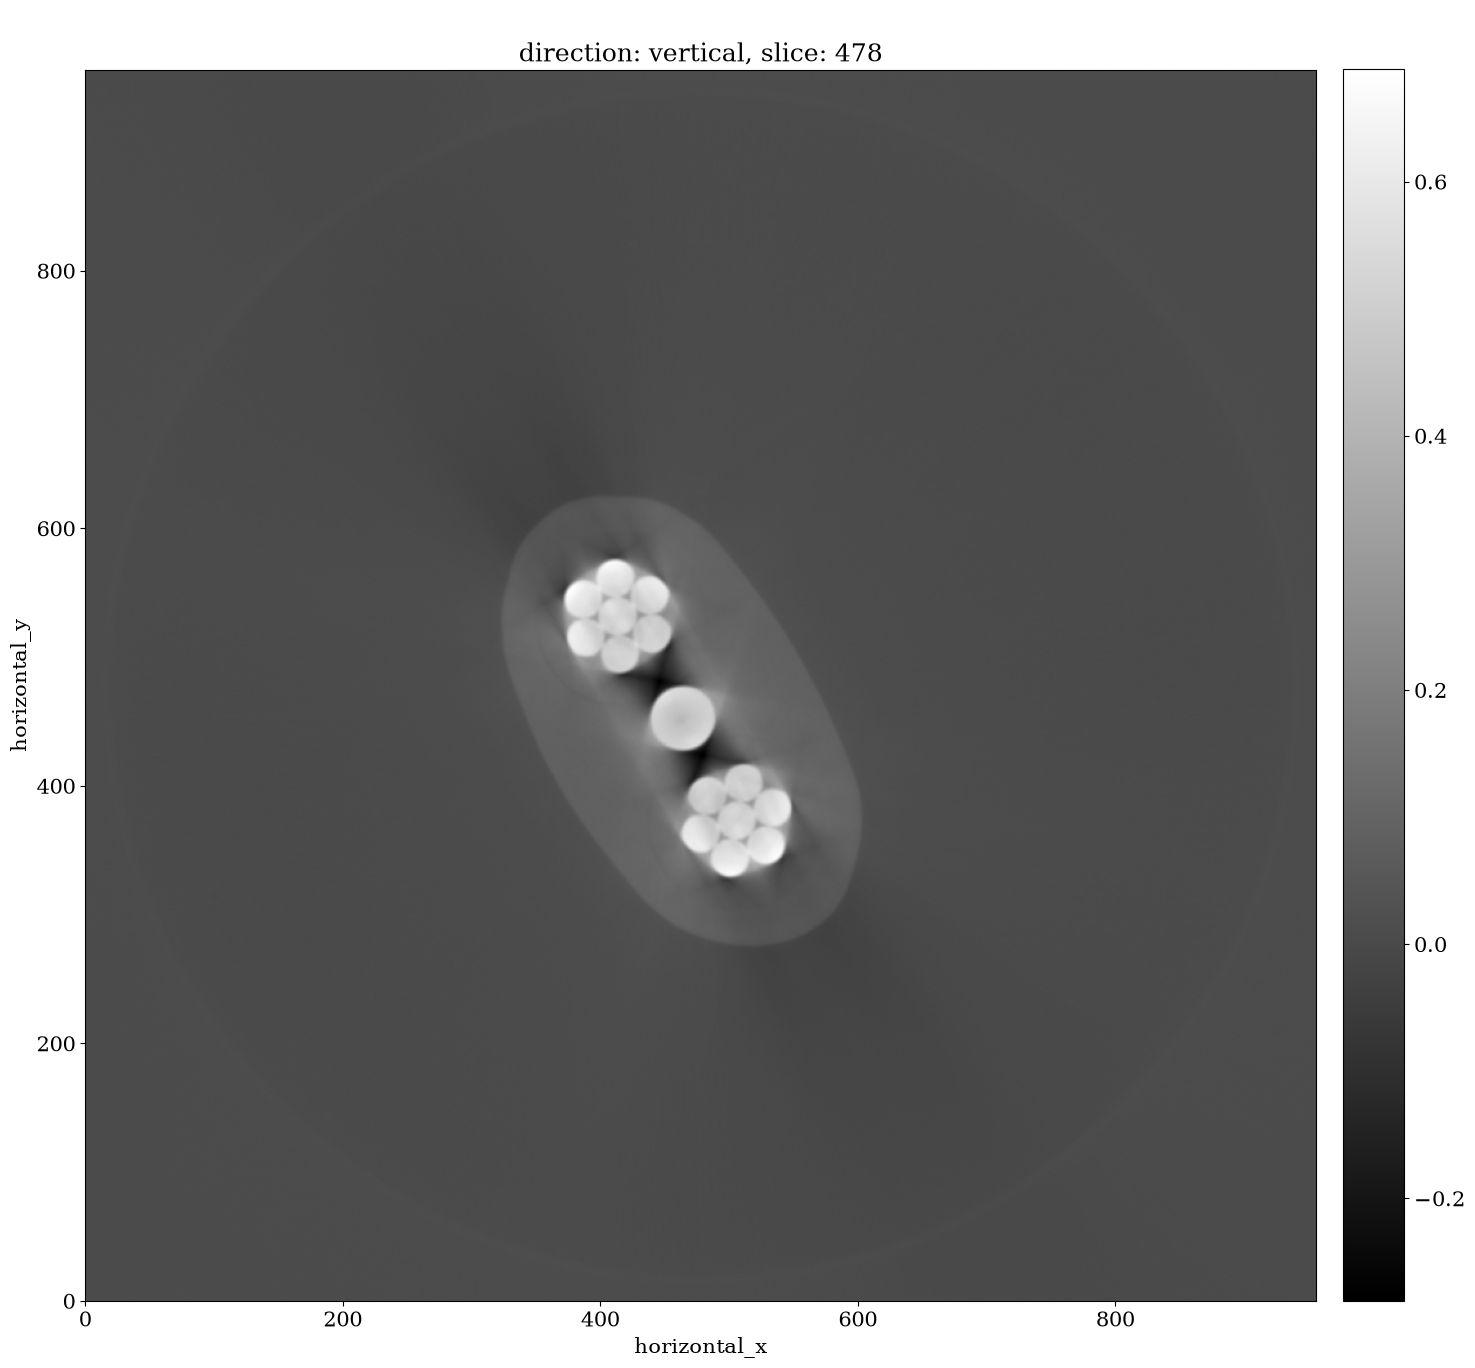

In [9]:
show2D(flexible_recon)

In [10]:
# The max path length through the sample would be ~13.48 mm

# 2. Setup the source spectrum and material
To ensure the gVXR simulations match the experimental parameters, configure the settings provided.

In this case, the `.mat` file is extensive enough to cover most of the required data but in the case where the information is not available in the file, the parameters should be input (see `tube_angle_degrees`).

Most importantly, include the material of the sample that most closely resembles the material of the sample being scanned. In the case of the HTC data, this material was Aluminium.

In [11]:
print(np.mean(flexible_data_exp.geometry.dist_center_detector))
print(flexible_data_exp.geometry.dist_source_center.max(), flexible_data_exp.geometry.dist_source_center.min())

460.14274706520564
60.91918434861058 60.91904564263954


In [12]:
material_of_sample = "Cu"       # Focus on highest attenuating material

# -----------------------------
# Units
# -----------------------------
unit_of_length : str = "cm"
tube_voltage_unit : str = "kV"

# -----------------------------
# Spectrum Characteristics
# -----------------------------
tube_angle_degrees : float = 12.0
tube_voltage_kV : float = 100.0

# -----------------------------
# Filter Characteristics
# -----------------------------
filter_material : str = "Cu"
filter_thickness : float = 2.0

In [13]:
# ---------------------------------------------------------------
# Geometry specific values
# ---------------------------------------------------------------
# TODO: Use automated reading of data as a future work point
# CIL has specific instructions as to how code can work with
# as flexible gemoetry as possible, so might make automated
# reader quite difficult
scan_geometry = flexible_data_exp.geometry.geom_type

# Counted from perpendicular of ray to detector
detector_origin_distance = np.mean(flexible_data_exp.geometry.dist_center_detector)
source_origin_distance = np.mean(flexible_data_exp.geometry.dist_source_center)

detector_rows, detector_columns = (
    num_voxel_xy,
    num_voxel_xy,
)

pixel_size = (
    flexible_data_exp.geometry.pixel_size_h,
    flexible_data_exp.geometry.pixel_size_v,
)

filter_unit = unit_of_length

In [14]:
gvxr.createOpenGLContext()

pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)
pci id for fd 126: 10de:1eb1, driver (null)
pci id for fd 127: 10de:1eb1, driver (null)


In [15]:
source_position = (-20.0, 0, 0)
detector_position = (detector_origin_distance, 0, 0)
detector_up_vector = (0, 0, -1)

# Detector Position and direction
gvxr.setDetectorPosition(*detector_position, unit_of_length)
gvxr.setDetectorUpVector(*detector_up_vector)

gvxr.setDetectorNumberOfPixels(detector_columns, detector_rows)
gvxr.setDetectorPixelSize(*pixel_size, unit_of_length)

# 3. Mirror the polychromatic X-ray source used in reconstruction

In [16]:
poly_spectrum_hist = setPolySpectrum(
    tube_voltage_kV,
    # filters=[[filter_material, filter_thickness, filter_unit]],
    filters=None,
    tube_angle_in_deg=tube_angle_degrees,
    mAs=300,
    unit="keV",
)

poly_spectrum_bins, poly_spectrum_photons = zip(*poly_spectrum_hist.items(), strict=False)

# Source position
gvxr.setSourcePosition(
    *source_position,
    unit_of_length,
)

# Source type
gvxr.usePointSource()
# gvxr.useParallelBeam()

In [17]:
average_energy = np.sum(np.array(poly_spectrum_photons) * np.array(poly_spectrum_bins)) / np.sum(poly_spectrum_photons)

In [92]:
detector_width, detector_height = gvxr.getDetectorSize("mm")

step_wedge_name = "step-wedge"
step_wedge_material = material_of_sample
number_of_steps = 10
step_wedge_length = detector_width * 0.03
step_wedge_width = detector_height * 0.03

# step_wedge_height = find_optimal_stepwedge_size(
#     flexible_data_exp,
#     step_wedge_material,
#     tolerance=flexible_recon.array.max()*0.01,
#     max_iterations=50,
# )

In [93]:
step_wedge_height = 1.57

step_height = step_wedge_height / number_of_steps

In [94]:
gvxr.removePolygonMeshesFromSceneGraph()

gvxr.makeStepWedge(
    step_wedge_name,
    number_of_steps,  # Number of steps
    step_wedge_length,
    step_wedge_width,
    step_height,
    step_height,
    "mm",
)

gvxr.addPolygonMeshAsOuterSurface(step_wedge_name)

gvxr.setElement(step_wedge_name, step_wedge_material)

gvxr.rotateNode(step_wedge_name, 90, 0, 90)
gvxr.translateNode(
    step_wedge_name,
    0,
    0,
    -step_wedge_height * 0.5,
    "mm",
)

x_ray_poly_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

print(step_wedge_height)

1.57


# 4. Get a projection with the equivalent monochromatic energy

In [95]:
gvxr.setMonoChromatic(average_energy, "keV", 1000)

x_ray_mono_image = (
    np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse()
)

In [96]:
print(average_energy)

27.58601224160389


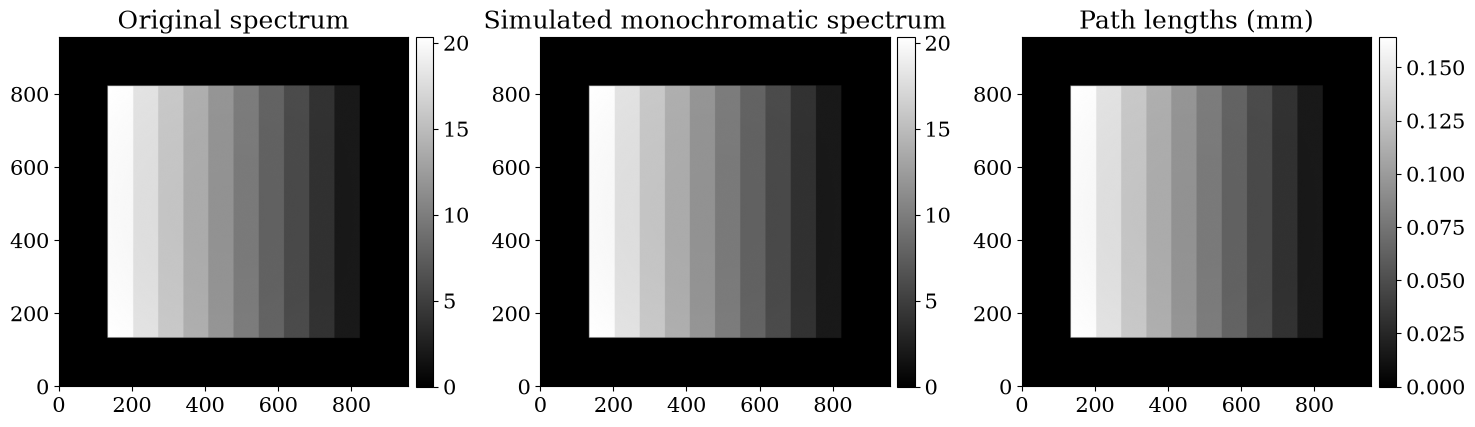

In [ ]:
x_ray_L_buffer = np.array(gvxr.getLastLBuffer(), dtype=np.single)           # L-Buffer (path lengths)
x_ray_mono_image_absorption = transmission_to_absorption(x_ray_mono_image)  # Monochromatic source projection
x_ray_poly_image_absorption = transmission_to_absorption(x_ray_poly_image)  # Scan reconstruction

show2D([x_ray_poly_image_absorption, x_ray_mono_image_absorption, x_ray_L_buffer], ["Original spectrum", "Simulated monochromatic spectrum", "Path lengths (mm)"], num_cols = 3)

# 5. Polychromatic fitting of spectra

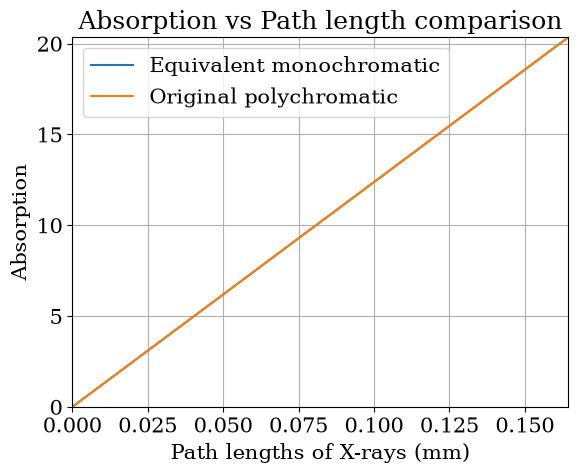

In [98]:
lookup_table_indices = np.argsort(np.ravel(x_ray_poly_image_absorption))
polychromatic_sorted_values = np.ravel(x_ray_poly_image_absorption)[lookup_table_indices]
monochromatic_sorted_values = np.ravel(x_ray_mono_image_absorption)[lookup_table_indices]

L_buffer_sorted_values = np.ravel(x_ray_L_buffer)[lookup_table_indices]

plt.close("all")

plt.plot(
    L_buffer_sorted_values, monochromatic_sorted_values, label="Equivalent monochromatic"
)
plt.plot(
    L_buffer_sorted_values, polychromatic_sorted_values, label="Original polychromatic"
)
plt.legend()
plt.grid(True)
plt.title("Absorption vs Path length comparison")
plt.xlabel("Path lengths of X-rays (mm)")
plt.ylabel("Absorption")
plt.xlim(0,max(L_buffer_sorted_values))
plt.ylim(0,max(monochromatic_sorted_values))
plt.show()

In [80]:
monochromatic_coefficients = np.polynomial.polynomial.polyfit(
    L_buffer_sorted_values,
    monochromatic_sorted_values,
    1,
)

poly_order_limit = 10

fitted_polychromatic_values = get_optimal_poly_fit(L_buffer_sorted_values, polychromatic_sorted_values, poly_order_limit)

/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/ubuntu/miniforge3/envs/gvxr-tutorials/lib/python3.11/site-packages/numpy/polynomial/polynomial.py:1445: RankWarning: The fit may be poorly con

# 6. The CIL Beam hardening correction processor

In [81]:
copy_aq_data = flexible_data_exp.copy()

In [82]:
from BeamHardeningCorrector import BeamHardeningCorrector
from cil.utilities.display import show2D

processor = BeamHardeningCorrector(
    fitted_polychromatic_values.coefficients,
    monochromatic_coefficients[1],
    step_wedge_height * 0.1,
    step_wedge_height * 0.001,
)

processor.set_input(copy_aq_data)
corrected_aq_data = processor.get_output()

In [83]:
fdk = FBP(image_geometry, flexible_data_exp.geometry)
fdk.set_input(corrected_aq_data)

# Perform the actual CT reconstruction
corrected_recon = fdk.get_output()

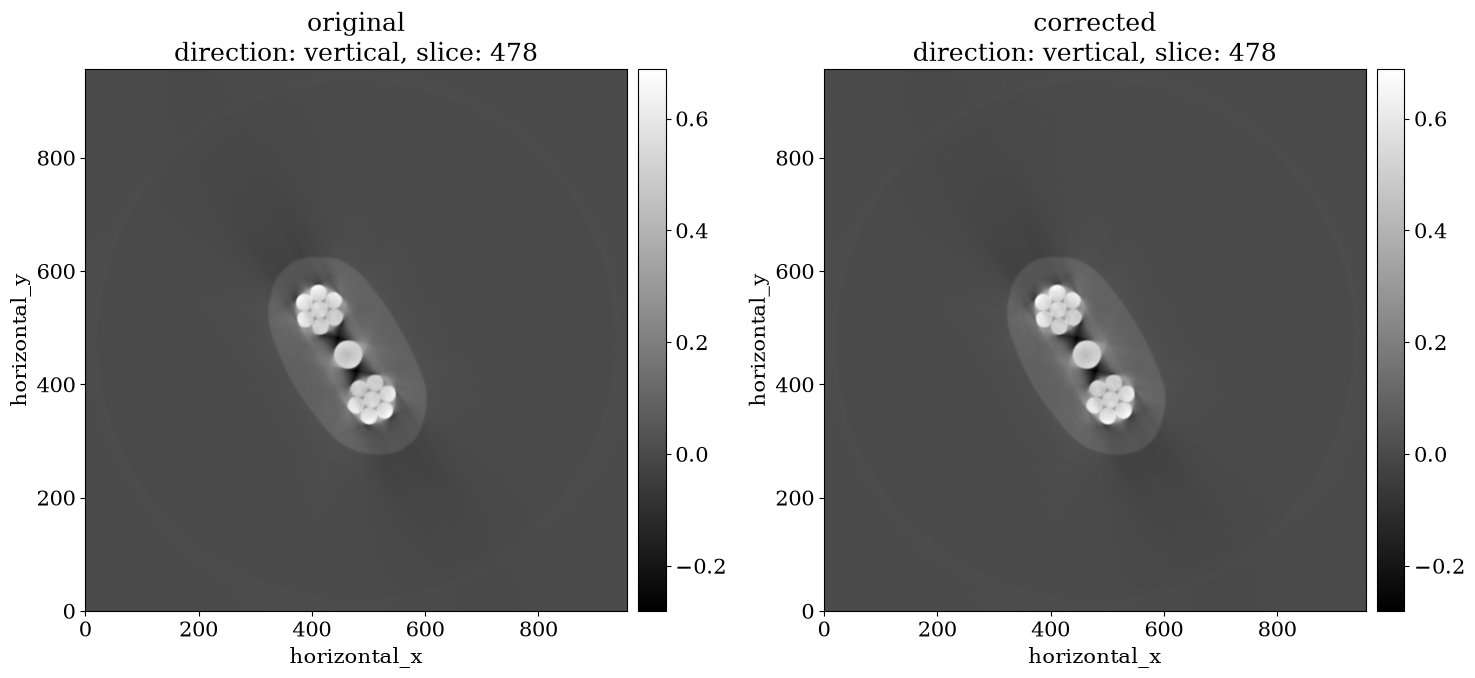

In [84]:
show2D([flexible_recon, corrected_recon], ["original", "corrected"])

In [85]:
o_writer = TIFFWriter(flexible_recon, os.path.join(OUTPUT_PATH, "orig_recon"))
o_writer.write()
p_writer = TIFFWriter(corrected_recon, os.path.join(OUTPUT_PATH, "corr_recon"))
p_writer.write()

# img-mean/std_dev
# line profile on both axes and another one purely in plastic and another in copper